In [1]:
!pip install kraken

import warnings
import logging

# Suppress all warnings
warnings.filterwarnings("ignore")

# Suppress Kraken + Shapely logs
logging.getLogger("kraken").setLevel(logging.CRITICAL)
logging.getLogger("shapely").setLevel(logging.CRITICAL)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 61.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.3/114.3 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 102.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 51.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scip

In [2]:
!wget -O seg_model.mlmodel https://github.com/mittagessen/kraken/raw/main/kraken/blla.mlmodel

--2026-04-12 04:12:50--  https://github.com/mittagessen/kraken/raw/main/kraken/blla.mlmodel
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mittagessen/kraken/main/kraken/blla.mlmodel [following]
--2026-04-12 04:12:51--  https://raw.githubusercontent.com/mittagessen/kraken/main/kraken/blla.mlmodel
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5047020 (4.8M) [application/octet-stream]
Saving to: ‘seg_model.mlmodel’

seg_model.mlmodel   100%[===================>]   4.81M  --.-KB/s    in 0.07s   

2026-04-12 04:12:51 (64.3 MB/s) - ‘seg_model.mlmodel’ saved [5047020/5047020]



In [5]:
from PIL import Image

imgPath = '/kaggle/input/datasets/alwynsajan/kraken-data/0430.tif'

img = Image.open(imgPath).convert('RGB').convert('L')

# Resize for better speed + stability
img = img.resize((img.width // 2, img.height // 2))

print("Image size:", img.size)

Image size: (1346, 1744)


In [6]:
from kraken import blla
from kraken.lib import vgsl

model = vgsl.TorchVGSLModel.load_model('seg_model.mlmodel')

result = blla.segment(img, model=model)

print("Lines detected:", len(result.lines))
print("Regions detected:", len(result.regions))

Lines detected: 461
Regions detected: 1


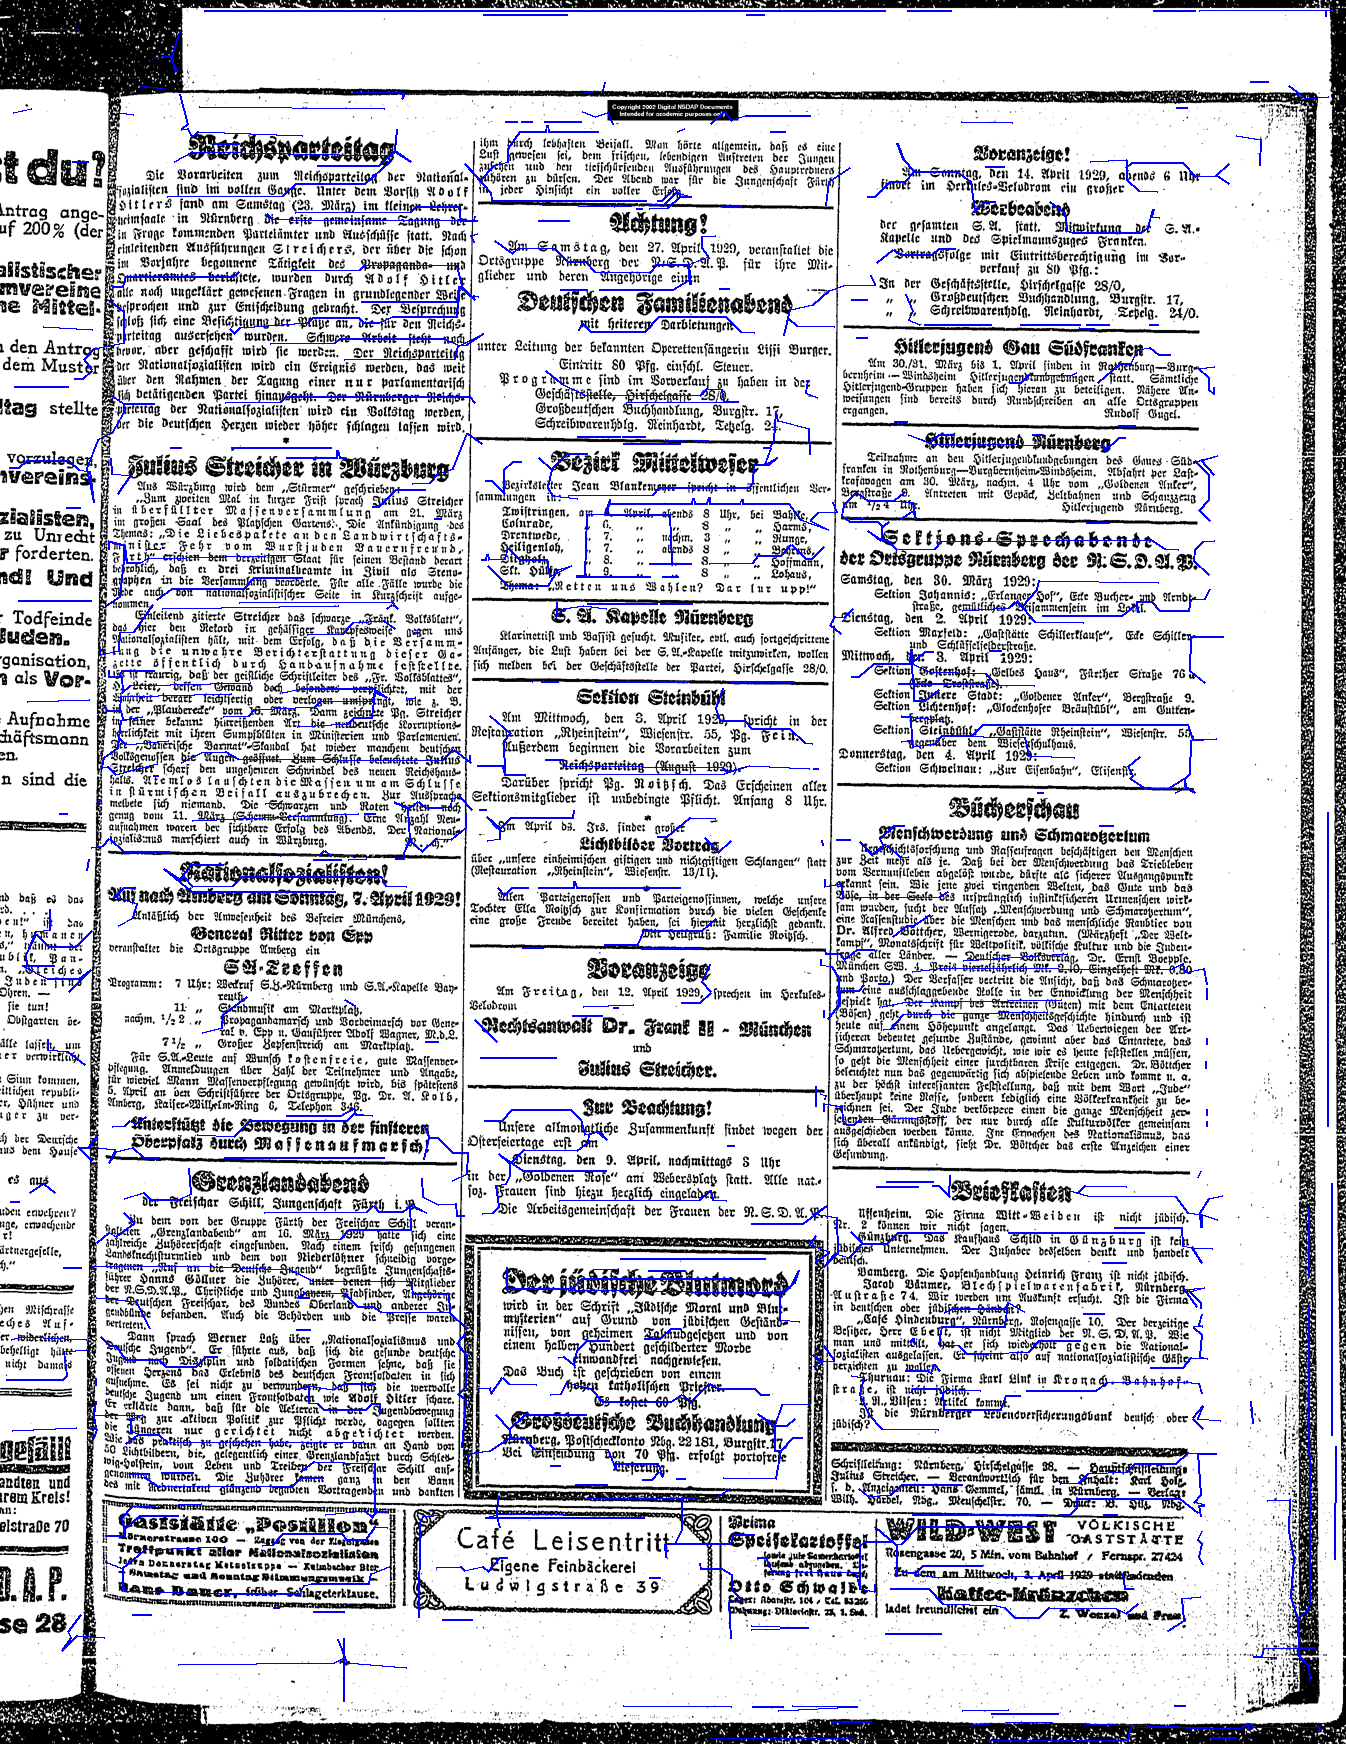

In [8]:
from PIL import ImageDraw

imgVis = img.convert("RGB")
draw = ImageDraw.Draw(imgVis)

for line in result.lines:
    draw.line(line.baseline, fill="blue", width=2)

display(imgVis)